Continuation of the last notebook, messing around with the graphs here so its more cleaned up and can run faster. Explanations in the last notebook.

In [13]:
import math
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm.notebook import tqdm



In [14]:
class Module(object):
    def __init__(self, *_args, seed=None, rnd=None, dtype=np.float64, **_kwargs):
        if rnd is None:
            self.rnd = np.random.default_rng(seed)
        else:
            self.rnd = rnd
        self.dtype = dtype


class Linear(Module):
    def __init__(self, input_dim: int, output_dim: int, bound: float = None, bias: float = 0.0, **kwargs):
        """
        Linear model

        Args:
            input_dim (int): input dimension
            output_dim (int): output dimension
            bound (float, optional): sampling scale for weight. Defaults to None.
            bias (float, optional): sampling scale for bias. Defaults to 0.0.
        """
        super(Linear, self).__init__(**kwargs)
        self.input_dim = input_dim
        self.output_dim = output_dim
        if bound is None:
            bound = math.sqrt(1 / input_dim)
        self.weight = self.rnd.uniform(-bound, bound, (output_dim, input_dim)).astype(self.dtype)
        self.bias = self.rnd.uniform(-bias, bias, (output_dim,)).astype(self.dtype)

    def __call__(self, x: np.ndarray):
        x = np.asarray(x)
        out = np.matmul(x, self.weight.swapaxes(-1, -2)) + self.bias
        return out


def solution(input_dim, output_dim, seed, bound, bias, mat):
    lin = Linear(input_dim, output_dim, bound=bound, bias=bias, seed=seed)
    return lin(mat)

In [15]:
class LRReadout(Linear):
    def train(self, x: np.ndarray, y: np.ndarray):
        assert (x.ndim == 2) and (x.shape[-1] == self.input_dim)
        assert (y.ndim == 2) and (y.shape[-1] == self.output_dim)
        # Calculate the optimal weight and bias.
        x_biased = np.ones((x.shape[0], x.shape[1] + 1), dtype=self.dtype)
        x_biased[:, 1:] = x
        sol, _residuals, _rank, _s = np.linalg.lstsq(x_biased, y, rcond=None)
        self.weight[:] = sol[1:].T
        self.bias[:] = sol[0]
        return self.weight, self.bias


def solution(dim_in, dim_out, x_train, y_train, x_eval):
    readout = LRReadout(dim_in, dim_out)
    readout.train(x_train, y_train)
    return readout(x_eval)

In [16]:
def calc_nrmse(y, yhat):
    mse = y - yhat
    mse = (mse * mse).mean(axis=0)
    var = y.var(axis=0)
    return (mse / var) ** 0.5


In [17]:
def logistic_func(z, a=4.0):
    z_dot = a * z * (1 - z)
    return z_dot

def generate_logistic_series(start=0.1,a=4.0,length=100):
    series = [start]
    for _ in range(length - 1):
        next_value = logistic_func(series[-1], a)
        series.append(next_value)
    return series



In [18]:
def Ry(states, index, angle):
    k = 2**index                  #representing the qubit as the integer of that qubit being 1
                                  #i^k is the index corresponding to the same state but with the index qubit flipped
    c = np.cos(angle / 2).item()
    s = np.sin(angle / 2).item()

    new_states = states.copy()

    for i in range(len(states)):
        j = i ^ k
        a = states[i]
        b = states[j]

        if j > i:           #this part calculates coefficient of the index qubit being 0
            new_states[i] = c*a - s*b
        else:                #this part calculates coefficient of the index qubit being 1
            new_states[i] = c*a + s*b

    return new_states


In [19]:
def Big_u(states):
  new_states=states.copy()
  n = int(np.log2(len(states)))

  for i in range(len(states)):
    j=newind(i,n)
    new_states[j]=states[i]
  return new_states

def newind(i,n):      #the index that state b4,b3,b2,b1,b0 (b is 1 or 0) is mapped to is (b4 xor b3 xor ... xor b0, b3 xor ... xor b0, b2 xor b1 xor b0, b1 xor b0, b0)
  j=0
  for a in range(n):  #cool trick for doing these xors
    j=j^((2**a)*i)
  return j%(2**n)

def evaluate(states): #gives the expected value of each qubit being 1, which we measure and feed into the next circuit as the ys
  p_states=states.copy()
  p_states*=states    #probability of each state

  ys=np.zeros(int(np.log2(len(states))))

  for y_ind in range(len(ys)):
    y_pow=2**y_ind

    for p_ind in range(len(p_states)):
      if p_ind^y_pow < y_pow:      #adds if the state at p_ind has qubit at y-ind = 1
        ys[y_ind] += p_states[p_ind]

  return ys


In [20]:
'''
def update_QR(ys,x,a,b):
  num=len(ys)   #gets number of qubits
  states=np.zeros(2**num)
  states[0]=1   #initialize all qubits at 0

  states=Ry(states,0,a*x)   #first set of rotations
  for j in range(1,num):
    states=Ry(states,j,b*ys[j-1])

  states=Big_u(states)      #U

  for j in range(num):      #second set of rotations
    states=Ry(states,j,b*ys[j])
  states=Big_u(states)
  for j in range(num):      #two rotations from the one at the end of B and start of B
    states=Ry(states,j,2*b*ys[j])
  states=Big_u(states)
  for j in range(num):      #last set of rotations
    states=Ry(states,j,b*ys[j])
  exp_values=evaluate(states)
  y_new=np.arccos(exp_values)
  return y_new
'''


def update_QR(ys,x,a,b):    #this one is modified by putting the input halfway through
  num=len(ys)   #gets number of qubits
  states=np.zeros(2**num)
  states[0]=1   #initialize all qubits at 0



  for j in range(num):      #second set of rotations
    states=Ry(states,j,b*ys[j])
  states=Big_u(states)

  states=Ry(states,0,a*x)   #first set of rotations
  for j in range(1,num):
    states=Ry(states,j,b*ys[j-1])

  states=Big_u(states)      #U

  for j in range(num):      #two rotations from the one at the end of B and start of B
    states=Ry(states,j,2*b*ys[j])
  states=Big_u(states)
  for j in range(num):      #last set of rotations
    states=Ry(states,j,b*ys[j])
  exp_values=evaluate(states)
  y_new=np.arccos(exp_values)
  return y_new





In [21]:
def qr_log_pred(a_logistic=3.7,num_nodes=5,a_param=-0.3,b_param=0.1,pred_steps=40,num_graphs=3,rnd_seed=1234):
  rnd = np.random.default_rng(rnd_seed)
  t_washout, t_train = 10, 200
  t_eval = pred_steps #guarantee enough data for plots
  t_total = t_washout + t_train + t_eval
  a=a_param
  b=b_param

  ts = np.arange(-t_washout, t_train + t_eval)
  ser = np.array(generate_logistic_series(rnd.random(),a_logistic,t_total+1)).reshape(-1,1)

  w_out = LRReadout(num_nodes, 1)

  vs = ser[1:]          #output we want
  us = ser[:-1]         #input
  xs = us.reshape(-1)


  ys=np.linspace(0,1,num_nodes) #start the reservoir at 0
  y_record = np.zeros((t_total, num_nodes)) #record of all states for training
  for idx in range(t_total):
      ys=update_QR(ys,xs[idx],a,b)
      y_record[idx] = ys


  x_train, v_train = y_record[t_washout:-t_eval], vs[t_washout:-t_eval]
  x_eval, v_eval = y_record[-t_eval:], vs[-t_eval:]
  w_out.train(x_train, v_train)
  v_out = w_out(x_eval)
  nrmse = calc_nrmse(v_eval, v_out).item()

  for w_ind in range(num_graphs):
    # --- Parameters ---
    warmup_steps = rnd.integers(t_washout , t_washout + t_train)       #simulate random initial conditions by starting prediction at different indices
    t_total = warmup_steps + pred_steps

    # --- Prepare storage ---
    ys = np.zeros(num_nodes)                # initial reservoir state
    v_gen = np.zeros((t_total, 1))   # generated output
    v_pred=0

    # --- Warmup: feed inputs to settle reservoir ---
    for idx in range(warmup_steps):
      ys=update_QR(ys,xs[idx],a,b)    # update reservoir
      v_pred = w_out(ys)            # compute output
      v_gen[idx] = v_pred          # store predicted output

    # --- Closed-loop prediction ---
    for idx in range(warmup_steps, t_total):
        ys=update_QR(ys,v_pred,a,b)        # update reservoir with last output
        v_pred = w_out(ys)            # predict next step
        v_gen[idx] = v_pred          # store prediction

    # --- Plot results of prediction ---
    plot_start = warmup_steps-4
    plt.figure(figsize=(10,4))
    time_steps = np.arange(-4, pred_steps)

    plt.plot(time_steps, v_gen[plot_start:], 'r', label='QR prediction')
    plt.plot(time_steps, vs[plot_start:t_total], 'k:', label='True series')

    plt.axvline(0, color='gray', linestyle='--', label='Warmup ends')

    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.title('Quantum Reservoir logistic Prediction (a= '+ str(a_logistic) + ')')  #want logistic constant a, not hyperparameter a

    plt.ylim(0, 1)  # <-- set y-axis range

    plt.legend()
    plt.show()
  return nrmse #for optimization

In [22]:
def heatMap(a_logistic=3.8,num_nodes=5,a_min=-1,a_max=1,b_min=-1,b_max=1,resolution=50,rnd_seed=1234):
  a_vals = np.linspace(a_min, a_max, resolution)
  b_vals = np.linspace(b_min, b_max, resolution)
  losses = np.full((resolution, resolution), np.nan)
  total_iters = len(a_vals) * len(b_vals)

  with tqdm(total=total_iters) as pbar:
      for i, a in enumerate(a_vals):
        if a != 0:
          for j, b in enumerate(b_vals):
            losses[i, j] = qr_log_pred(a_logistic, num_nodes, a, b, 40, 0, 1233)
            pbar.update(1)

  plt.imshow(
      losses.T,
      origin="lower",
      aspect="auto",
      extent=[a_vals[0], a_vals[-1], b_vals[0], b_vals[-1]],
      norm=LogNorm(),
      cmap="turbo" #more colorful color scheme
  )

  plt.xlabel("a")
  plt.ylabel("b")
  plt.colorbar(label="NRMSE")
  idx = np.unravel_index(np.argmin(losses), losses.shape)
  best_a = a_vals[idx[0]]
  best_b = b_vals[idx[1]]
  best_loss = losses[idx]
  arr=[best_a,best_b,best_loss]

  return arr



  0%|          | 0/22500 [00:00<?, ?it/s]

[np.float64(-0.0012080536912751662),
 np.float64(-0.010604026845637583),
 np.float64(4.106997654060107e-08)]

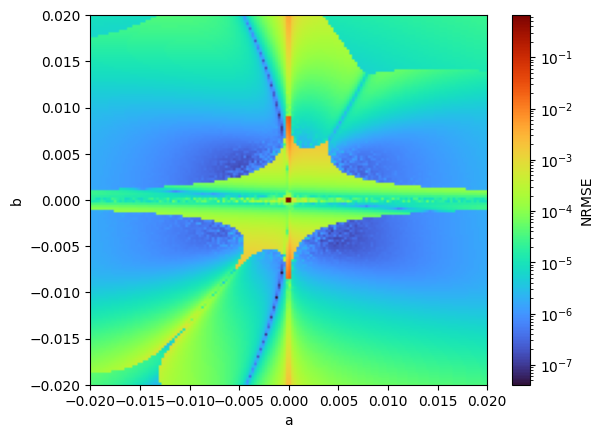

In [26]:
heatMap(3.8,5,-0.02,0.02,-0.02,0.02,150,1234)